In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

import warnings
warnings.filterwarnings('ignore')

# Ideas for future model improvement
Thoughts regarding each of the improvements below:
- Integrating domain knowledge: polyps do not go back to planulas.
- Integrating video knowledge: there are always the same number of things, AND they don't suddenly disappear: if a prediction is not within a certain distance from predictions in the previous image, it's not right and we can remove it
- Similarly, if there is no prediction within a certain distance of predictions in the previous image, it's not right and we can add from the previous image
- Overlap: think about this further

Essentially, for each new prediction $p_i$ in image $k$, we check image $k-1$ to determine if $p_i$ has a corresponding prediction that is close enough. What is "close enough"? That's up to the user, but I think w/in 20 pixels is a good starting point.
- If a prediction is NOT w/in a certain distance from a prediction in the previous image, we can remove it
- If a prediction from the previous image does NOT have a corresponding prediction w/in a certain distance in the current image, we can copy one over (introduces some small error which gets magnified over frames)

In [2]:
df = pd.read_csv("annotations_test.csv")
df.head()

,Unnamed: 0,image_filename,x1,y1,x2,y2,conf,class
0,0,glw_ac_16c_4_dpf_fert_04_10_20261314.png,643.28790,489.06598,652.81506,499.62698,0.930002,0.0
1,1,glw_ac_16c_4_dpf_fert_04_10_20261314.png,592.38367,389.81903,602.39280,400.38950,0.920628,0.0
2,2,glw_ac_16c_4_dpf_fert_04_10_20261314.png,699.93240,222.09018,711.63120,234.96510,0.911168,0.0
3,3,glw_ac_16c_4_dpf_fert_04_10_20261314.png,156.43477,634.05590,166.51900,644.86224,0.911006,0.0
4,4,glw_ac_16c_4_dpf_fert_04_10_20261314.png,543.77380,310.59440,554.41130,321.52216,0.906934,0.0


In [3]:
filenames = df["image_filename"].unique()
filenames = np.sort(filenames) #sorting only the filenames makes this a lot quicker later
df_individuals = []

for f in filenames:
    df_individuals.append(df[df.image_filename == f])

df_lens = [len(d) for d in df_individuals]

(array([457.,   0.,   0., 870.,   0.,   0., 459.,   0.,   0.,  13.]),
 array([18. , 18.3, 18.6, 18.9, 19.2, 19.5, 19.8, 20.1, 20.4, 20.7, 21. ]),
 <BarContainer object of 10 artists>)

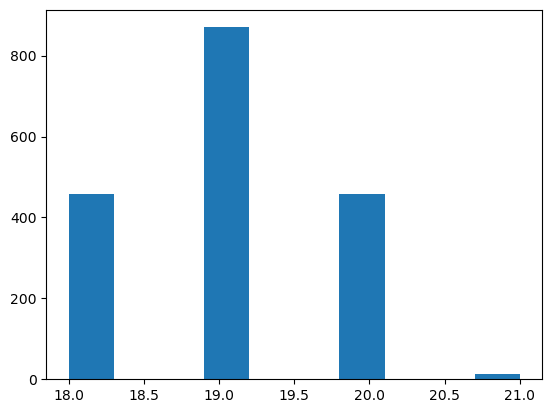

In [4]:
plt.hist(df_lens)

In [5]:
df_individuals[0]

,Unnamed: 0,image_filename,x1,y1,x2,y2,conf,class
29699,29699,glw_ac_16c_4_dpf_fert_04_10_20260001.png,814.16920,579.13870,823.80150,588.85364,0.926776,0.0
29700,29700,glw_ac_16c_4_dpf_fert_04_10_20260001.png,591.10223,390.81110,601.18976,401.72080,0.923731,0.0
29701,29701,glw_ac_16c_4_dpf_fert_04_10_20260001.png,156.53076,633.68540,166.75790,644.61584,0.913662,0.0
29702,29702,glw_ac_16c_4_dpf_fert_04_10_20260001.png,542.23250,308.48367,553.26105,319.19257,0.911262,0.0
29703,29703,glw_ac_16c_4_dpf_fert_04_10_20260001.png,276.39285,341.55508,287.12125,353.40200,0.909188,0.0
29704,29704,glw_ac_16c_4_dpf_fert_04_10_20260001.png,649.90326,832.62915,660.52140,843.74960,0.903688,0.0
29705,29705,glw_ac_16c_4_dpf_fert_04_10_20260001.png,559.04443,486.16632,569.70610,497.19305,0.901891,0.0
29706,29706,glw_ac_16c_4_dpf_fert_04_10_20260001.png,701.30650,221.41888,713.87990,233.82092,0.899892,0.0
29707,29707,glw_ac_16c_4_dpf_fert_04_10_20260001.png,643.41614,489.19485,653.04170,500.12863,0.893710,0.0
29708,29708,glw_ac_16c_4_dpf_fert_04_10_20260001.png,656.19055,453.44492,668.14760,464.95825,0.893004,0.0


## Overlap Removal
For every pair $j, k$ in every `df_individuals[i]`, we check the intersection over union (IoU) of $j, k$. If that IoU is above a certain tolerance level, we remove $j$ or $k$ arbitrarily (in this implementation, we only remove $k$). 

In [6]:
"""Intersection over Union for two boxes given in the form of arrays [x1, y1, x2, y2]."""
def iou(a, b):
    x1 = max(a[0], b[0])
    y1 = max(a[1], b[1])
    x2 = min(a[2], b[2])
    y2 = min(a[3], b[3])

    inter = max(0, x2 - x1) * max(0, y2 - y1)
    if inter == 0:
        return 0.0
    
    area_a = (a[2] - a[0]) * (a[3] - a[1])
    area_b = (b[2] - b[0]) * (b[3] - b[1])
    return inter / (area_a + area_b - inter)

def remove_overlap(df, tolerance = 0.8):
    remove = []

    for j in range(len(df)):
        remove.append(False)
        for k in range(j):
            box_a = [df.iloc[j]["x1"], df.iloc[j]["y1"], df.iloc[j]["x2"], df.iloc[j]["y2"]]
            box_b = [df.iloc[k]["x1"], df.iloc[k]["y1"], df.iloc[k]["x2"], df.iloc[k]["y2"]]

            overlap = iou(box_a, box_b)
            if overlap > tolerance:
                remove[-1] = True
                break
    
    df["remove"] = remove
    df = df[df["remove"] == False]
    return df #not entirely necessary since we modify df



In [7]:
remove_overlap(df_individuals[0], 0.9)

,Unnamed: 0,image_filename,x1,y1,x2,y2,conf,class,remove
29699,29699,glw_ac_16c_4_dpf_fert_04_10_20260001.png,814.16920,579.13870,823.80150,588.85364,0.926776,0.0,False
29700,29700,glw_ac_16c_4_dpf_fert_04_10_20260001.png,591.10223,390.81110,601.18976,401.72080,0.923731,0.0,False
29701,29701,glw_ac_16c_4_dpf_fert_04_10_20260001.png,156.53076,633.68540,166.75790,644.61584,0.913662,0.0,False
29702,29702,glw_ac_16c_4_dpf_fert_04_10_20260001.png,542.23250,308.48367,553.26105,319.19257,0.911262,0.0,False
29703,29703,glw_ac_16c_4_dpf_fert_04_10_20260001.png,276.39285,341.55508,287.12125,353.40200,0.909188,0.0,False
29704,29704,glw_ac_16c_4_dpf_fert_04_10_20260001.png,649.90326,832.62915,660.52140,843.74960,0.903688,0.0,False
29705,29705,glw_ac_16c_4_dpf_fert_04_10_20260001.png,559.04443,486.16632,569.70610,497.19305,0.901891,0.0,False
29706,29706,glw_ac_16c_4_dpf_fert_04_10_20260001.png,701.30650,221.41888,713.87990,233.82092,0.899892,0.0,False
29707,29707,glw_ac_16c_4_dpf_fert_04_10_20260001.png,643.41614,489.19485,653.04170,500.12863,0.893710,0.0,False
29708,29708,glw_ac_16c_4_dpf_fert_04_10_20260001.png,656.19055,453.44492,668.14760,464.95825,0.893004,0.0,False


0 dfs filtered
100 dfs filtered
200 dfs filtered
300 dfs filtered
400 dfs filtered
500 dfs filtered
600 dfs filtered
700 dfs filtered
800 dfs filtered
900 dfs filtered
1000 dfs filtered
1100 dfs filtered
1200 dfs filtered
1300 dfs filtered
1400 dfs filtered
1500 dfs filtered
1600 dfs filtered
1700 dfs filtered


(array([485.,   0.,   0.,   0.,   0., 906.,   0.,   0.,   0., 408.]),
 array([17. , 17.2, 17.4, 17.6, 17.8, 18. , 18.2, 18.4, 18.6, 18.8, 19. ]),
 <BarContainer object of 10 artists>)

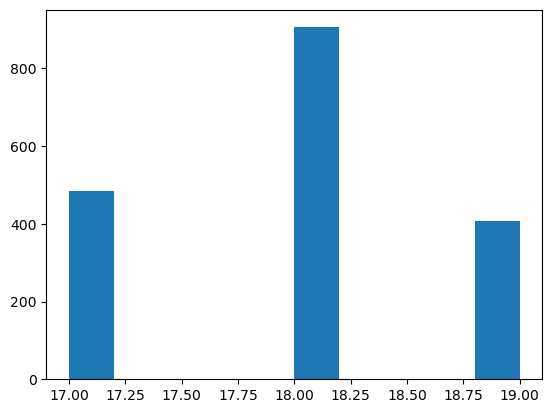

In [8]:
df_overlap_filtered = []
for i in range(len(df_individuals)):
    if i % 100 == 0:
        print(str(i) + " dfs filtered")
    df_overlap_filtered.append(remove_overlap(df_individuals[i], 0.9))

df_overlap_lens = [len(d) for d in df_overlap_filtered]
plt.hist(df_overlap_lens)

## Forward Imputation
Here, we take from `df_individuals[i]` (assuming it is correct) and add to `df_individuals[i+1]`. For every item $k$ in `df_individuals[i]`, we look and see if there is a corresponding prediction in `df_individuals[i+1]` within some distance of tolerance. If there is not, we add $k$ to `df_individuals[i+1]`.

In [9]:
def euclidean_distance(x1, y1, x2, y2):
    return np.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)

def get_distances(df_first, df_second, i, j):
    #get euclidean distance between these two points: top left corners first
    x1_tl = df_first.iloc[i]["x1"]
    y1_tl = df_first.iloc[i]["y1"]
    x2_tl = df_second.iloc[j]["x1"]
    y2_tl = df_second.iloc[j]["y1"]

    tl_dist = euclidean_distance(x1_tl, y1_tl, x2_tl, y2_tl)

    #now distance for bottom right corners
    x1_br = df_first.iloc[i]["x2"]
    y1_br = df_first.iloc[i]["y2"]
    x2_br = df_second.iloc[j]["x2"]
    y2_br = df_second.iloc[j]["y2"]

    br_dist = euclidean_distance(x1_br, y1_br, x2_br, y2_br)

    return tl_dist, br_dist

def forward_impute(df_first, df_second, tolerance = 20):
    df_new = df_second
    #look at every pair of items in first df, items in second df
    for i in range(len(df_first)):
        close_point_found = False
        for j in range(len(df_second)):
            tl_dist, br_dist = get_distances(df_first, df_second, i, j)
            #in this case, we've found a point that is close enough to the original point
            if tl_dist < tolerance or br_dist < tolerance:
                close_point_found = True
                break
        
        #here, we've either gone through all the point pairs OR found a point close enough
        if close_point_found == False:
            df_new = pd.concat([df_new, df_first.iloc[i]])

    return df_new 


0 dfs imputed
100 dfs imputed
200 dfs imputed
300 dfs imputed
400 dfs imputed
500 dfs imputed
600 dfs imputed
700 dfs imputed
800 dfs imputed
900 dfs imputed
1000 dfs imputed
1100 dfs imputed
1200 dfs imputed
1300 dfs imputed
1400 dfs imputed
1500 dfs imputed
1600 dfs imputed
1700 dfs imputed


(array([457.,   0.,   0., 870.,   0.,   0., 458.,   0.,   0.,  13.]),
 array([18. , 18.3, 18.6, 18.9, 19.2, 19.5, 19.8, 20.1, 20.4, 20.7, 21. ]),
 <BarContainer object of 10 artists>)

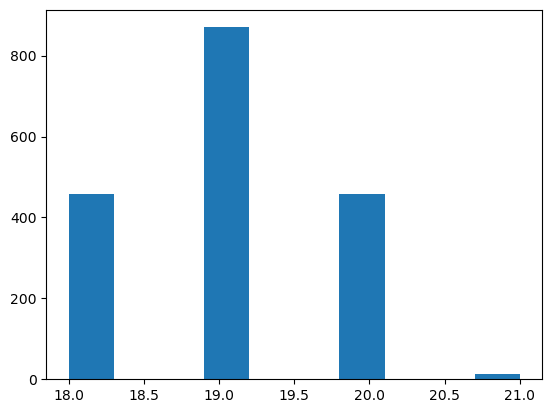

In [10]:
df_forward = []
for i in range(len(df_individuals) - 1):
    if i % 100 == 0:
        print(str(i) + " dfs imputed")
    df_forward.append(forward_impute(df_individuals[i], df_individuals[i+1]))

df_forward_lens = [len(d) for d in df_forward]
plt.hist(df_forward_lens)

## Backward Validation
Here, we take from `df_individuals[i+1]` and modify ITSELF by looking at `df_individuals[i]` (assuming it is correct). For every item $k$ in `df_individuals[i+1]`, we look and see if there is a corresponding prediction in `df_individuals[i]` within some distance of tolerance. If there is not, we remove $k$ from `df_individuals[i+1]`. 

In [13]:
def backward_val(df_first, df_second, tolerance = 20):
    remove = []

    for j in range(len(df_second)):
        close_point_found = False
        for i in range(len(df_first)):
            tl_dist, br_dist = get_distances(df_first, df_second, i, j)

            #in this case, we've found a point that is close enough to the original point
            if tl_dist < tolerance or br_dist < tolerance:
                close_point_found = True
                break
        
        #keep track of whether or not we've found a close enough point
        remove.append(close_point_found)

    df_second["remove"] = remove
    return df_second[df_second["remove"] == True]
    

0 dfs validated
100 dfs validated
200 dfs validated
300 dfs validated
400 dfs validated
500 dfs validated
600 dfs validated
700 dfs validated
800 dfs validated
900 dfs validated
1000 dfs validated
1100 dfs validated
1200 dfs validated
1300 dfs validated
1400 dfs validated
1500 dfs validated
1600 dfs validated
1700 dfs validated


(array([457.,   0.,   0., 870.,   0.,   0., 458.,   0.,   0.,  13.]),
 array([18. , 18.3, 18.6, 18.9, 19.2, 19.5, 19.8, 20.1, 20.4, 20.7, 21. ]),
 <BarContainer object of 10 artists>)

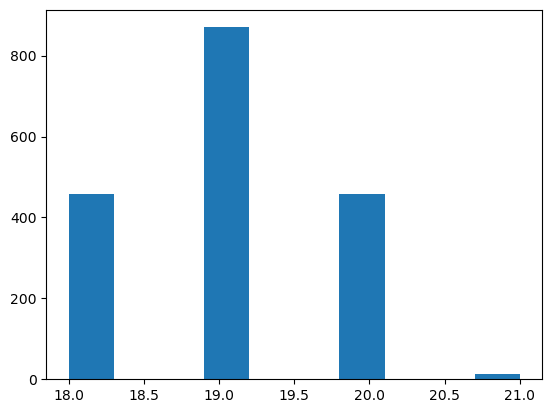

In [14]:
df_backward = []
for i in range(len(df_individuals) - 1):
    if i % 100 == 0:
        print(str(i) + " dfs validated")
    df_backward.append(backward_val(df_individuals[i], df_individuals[i+1]))

df_backward_lens = [len(d) for d in df_backward]
plt.hist(df_backward_lens)

(array([485.,   0.,   0.,   0.,   0., 906.,   0.,   0.,   0., 408.]),
 array([17. , 17.2, 17.4, 17.6, 17.8, 18. , 18.2, 18.4, 18.6, 18.8, 19. ]),
 <BarContainer object of 10 artists>)

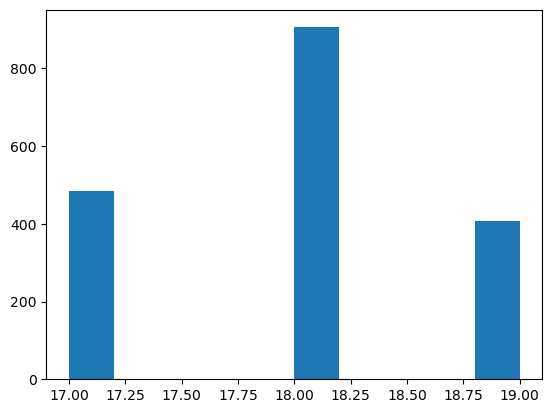

In [15]:
df_processed = []
for i in range(len(df_individuals)):
    df_processed.append(remove_overlap(df_individuals[i], 0.9))

for i in range(len(df_individuals) - 1):
    df_processed[i+1] = forward_impute(df_processed[i], df_processed[i+1])

for i in range(len(df_individuals) - 1):
    df_processed[i+1] = backward_val(df_processed[i], df_processed[i+1])

df_processed_lens = [len(d) for d in df_processed]
plt.hist(df_processed_lens)